## Problem 1

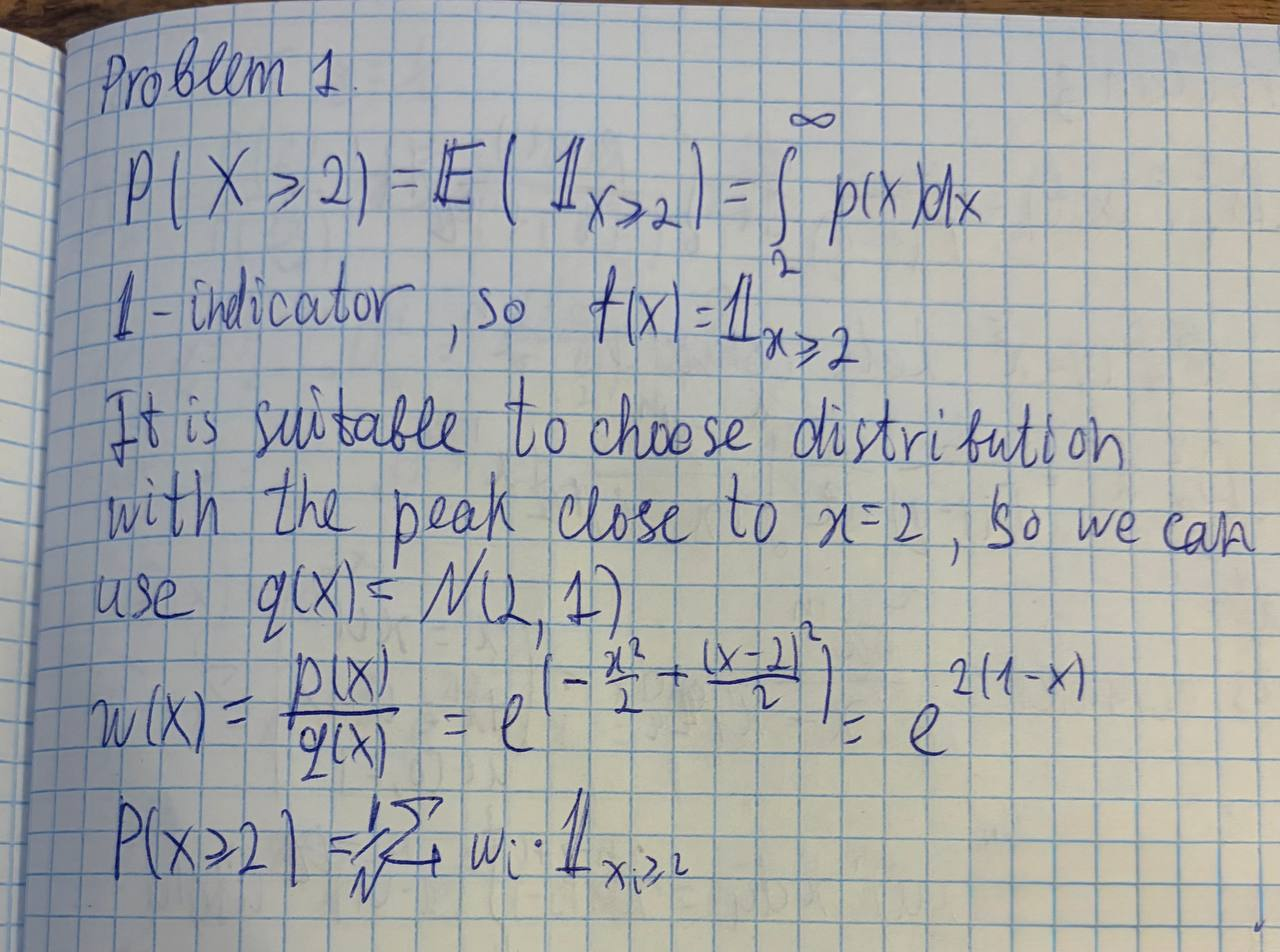

True probability: 0.02275013194817921


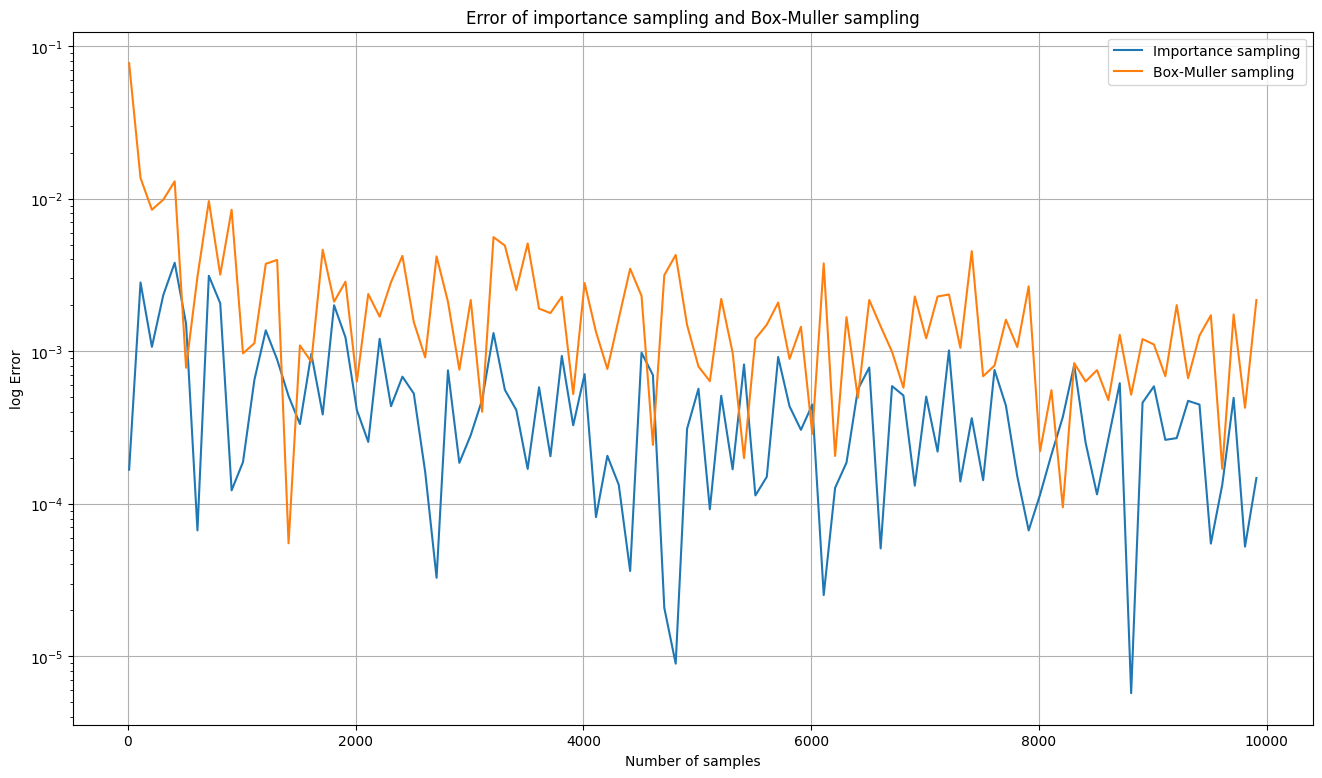

In [138]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf


def importance_sampling(N: int, rng: np.random.Generator) -> float:
    """Importance sampling"""
    x = rng.normal(loc=2, scale=1, size=N)
    weights = np.exp(2 - 2 * x)
    indicator = np.where(x > 2, 1, 0)

    return np.mean(weights * indicator)

def box_muller(N: int, rng: np.random.Generator) -> float:
    """Box-Muller sampling"""
    u1 = rng.uniform(size=N)
    u2 = rng.uniform(size=N)
    x = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)

    return sum(x > 2) / N


true_probability = 0.5 * (1 - erf(np.sqrt(2)))
rng = np.random.default_rng(42)

print(f"True probability: {true_probability}")

sampling_error = []
box_muller_error = []
n_values = np.arange(10, 10000, 100)

for n in n_values:
    sampling_error.append(np.abs(importance_sampling(n, rng) - true_probability))
    box_muller_error.append(np.abs(box_muller(n, rng) - true_probability))

plt.figure(figsize=(16, 9))
plt.title("Error of importance sampling and Box-Muller sampling")
plt.xlabel("Number of samples")
plt.ylabel("log Error")
plt.plot(n_values, sampling_error, label="Importance sampling")
plt.plot(n_values, box_muller_error, label="Box-Muller sampling")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()




## Problem 2

Lets choose proposal distribution as N(x, 1). As normal distribution is symmetric, then $K_{x,y} = K_{y,x}$  

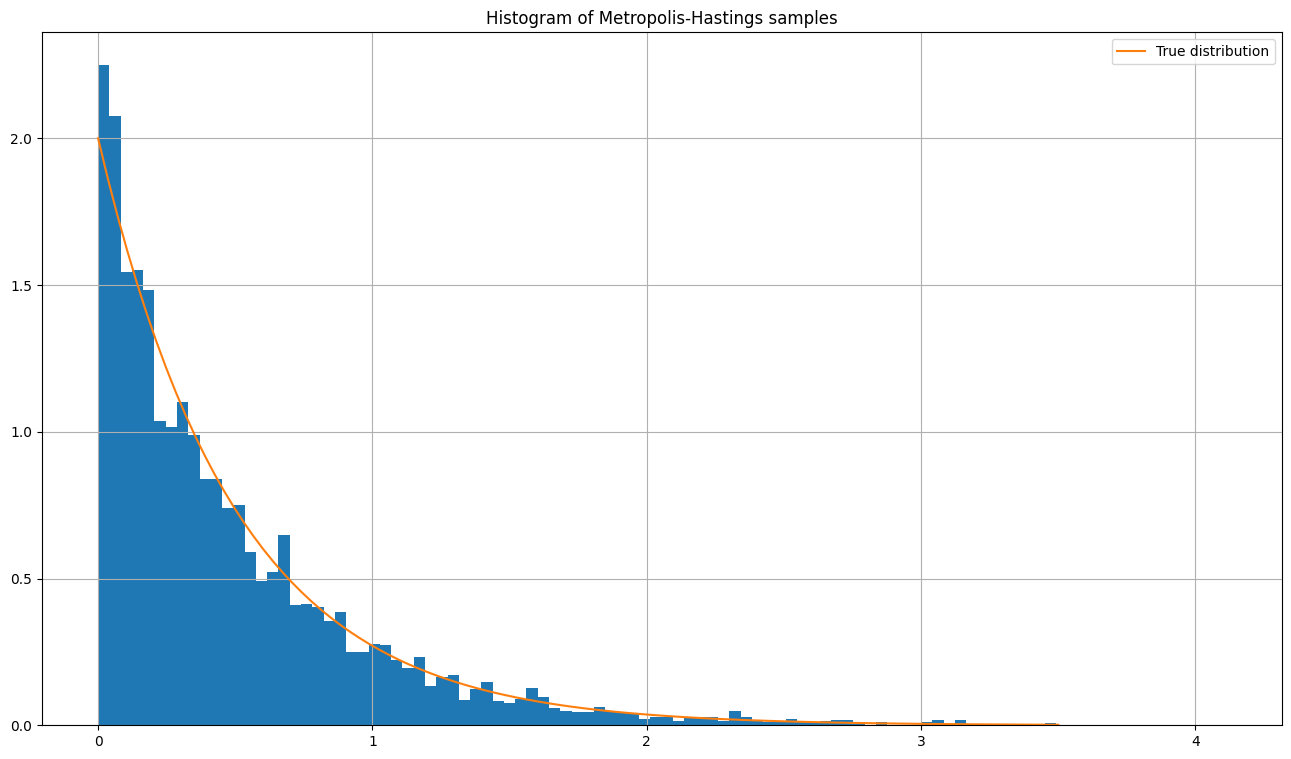

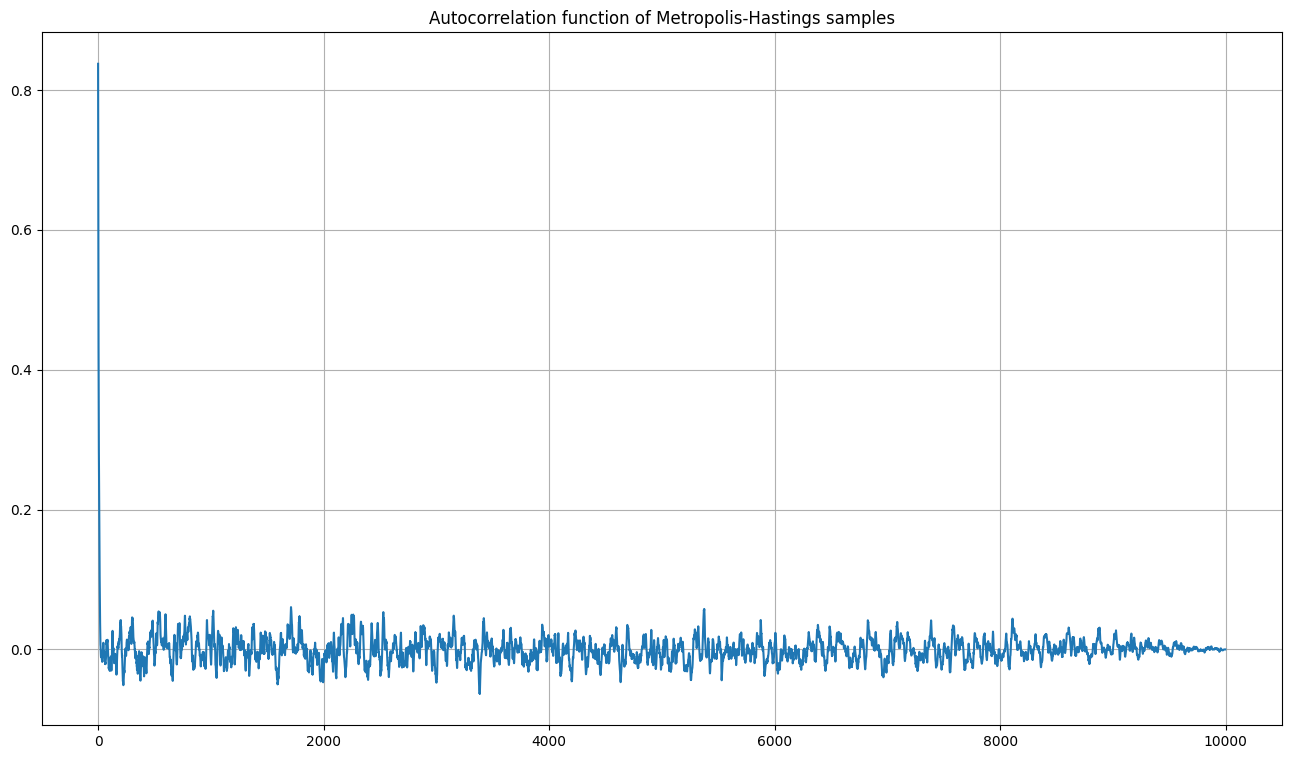

In [139]:
import numpy as np
import matplotlib.pyplot as plt

def MH_sampler(N: int, rng: np.random.Generator, samples_to_skip: int = 100) -> float:
    """Metropolis-Hastings sampler"""
    x = rng.uniform(0, 1)
    samples = np.zeros(N + samples_to_skip)

    for i in range(N + samples_to_skip):
        y = rng.normal(x, 1)

        if y < 0:
            samples[i] = x
            continue

        r_xy = min(1, np.exp(-2*( y - x)))

        if rng.uniform(0, 1) <= r_xy:
            x = y

        samples[i] = x

    return samples[samples_to_skip:]

rng = np.random.default_rng(42)
samples = MH_sampler(10000, rng, 1000)


x = np.linspace(0, 3.5, 100)
plt.figure(figsize=(16, 9))
plt.hist(samples, bins=100, density=True)
plt.grid()
plt.title("Histogram of Metropolis-Hastings samples")
plt.plot(x, 2*np.exp(-2*x), label="True distribution")
plt.legend()
plt.show()

def acf(x: list[float], k: int) -> list[float]:
    """Compute the autocorrelation function"""
    m = np.mean(x)
    var = np.var(x)

    return sum([(x[i] - m) * (x[i+k] - m) for i in range(len(x) - k)]) / (var * len(x))

autocorrelation = [acf(samples, k) for k in range(1, len(samples))]

plt.figure(figsize=(16, 9))
plt.plot(autocorrelation)
plt.title("Autocorrelation function of Metropolis-Hastings samples")
plt.grid(True)
plt.show()


## Problem 3

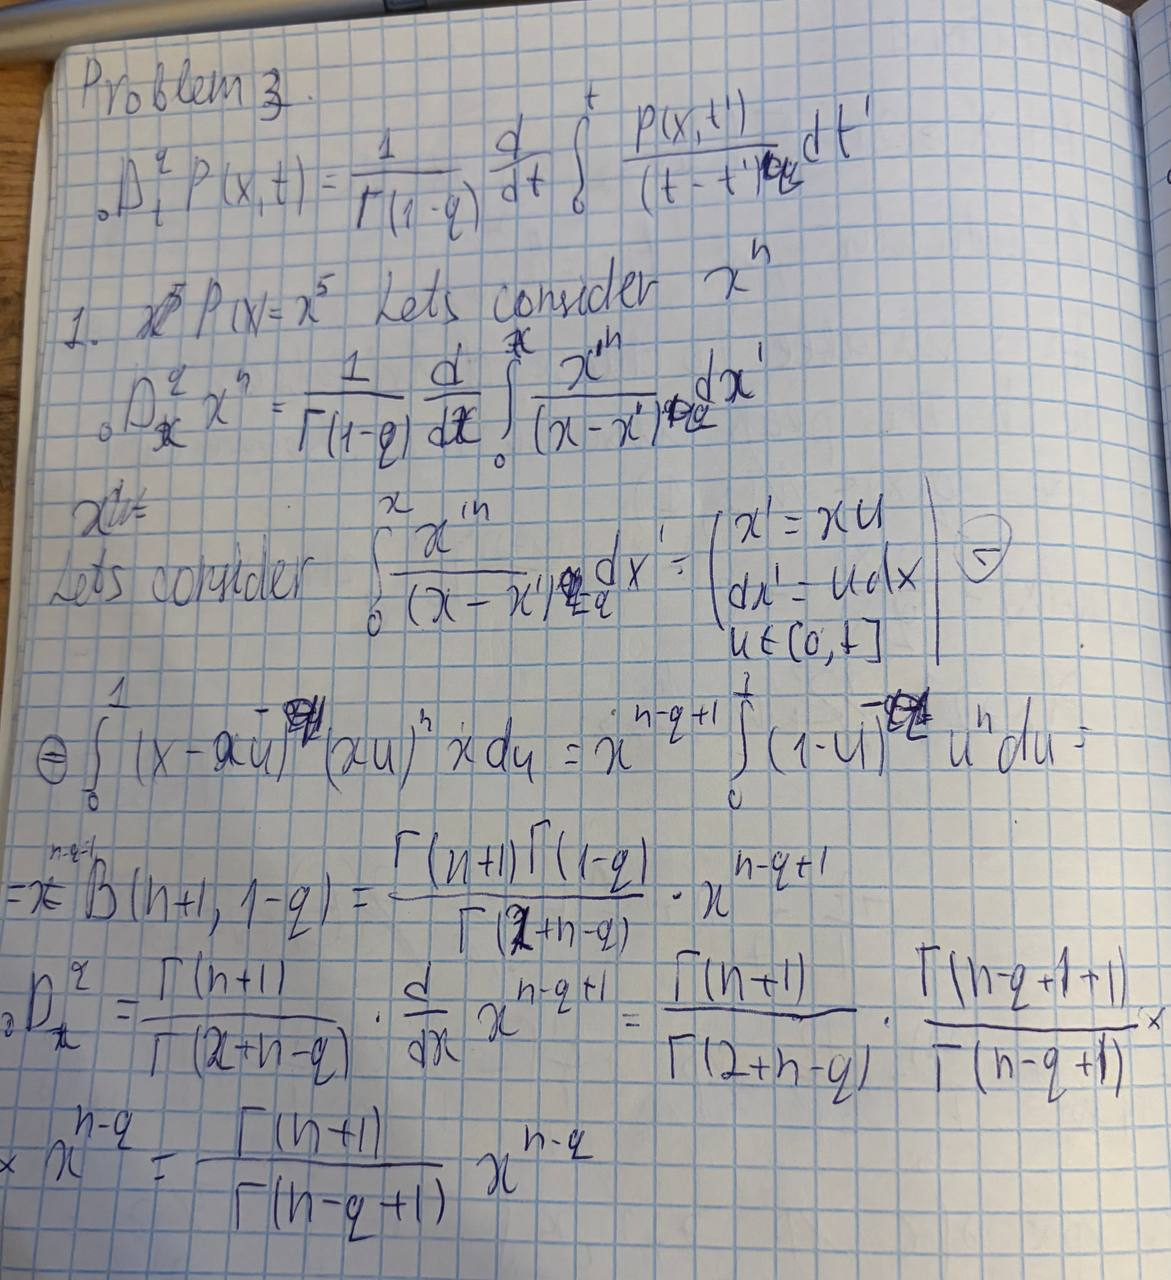

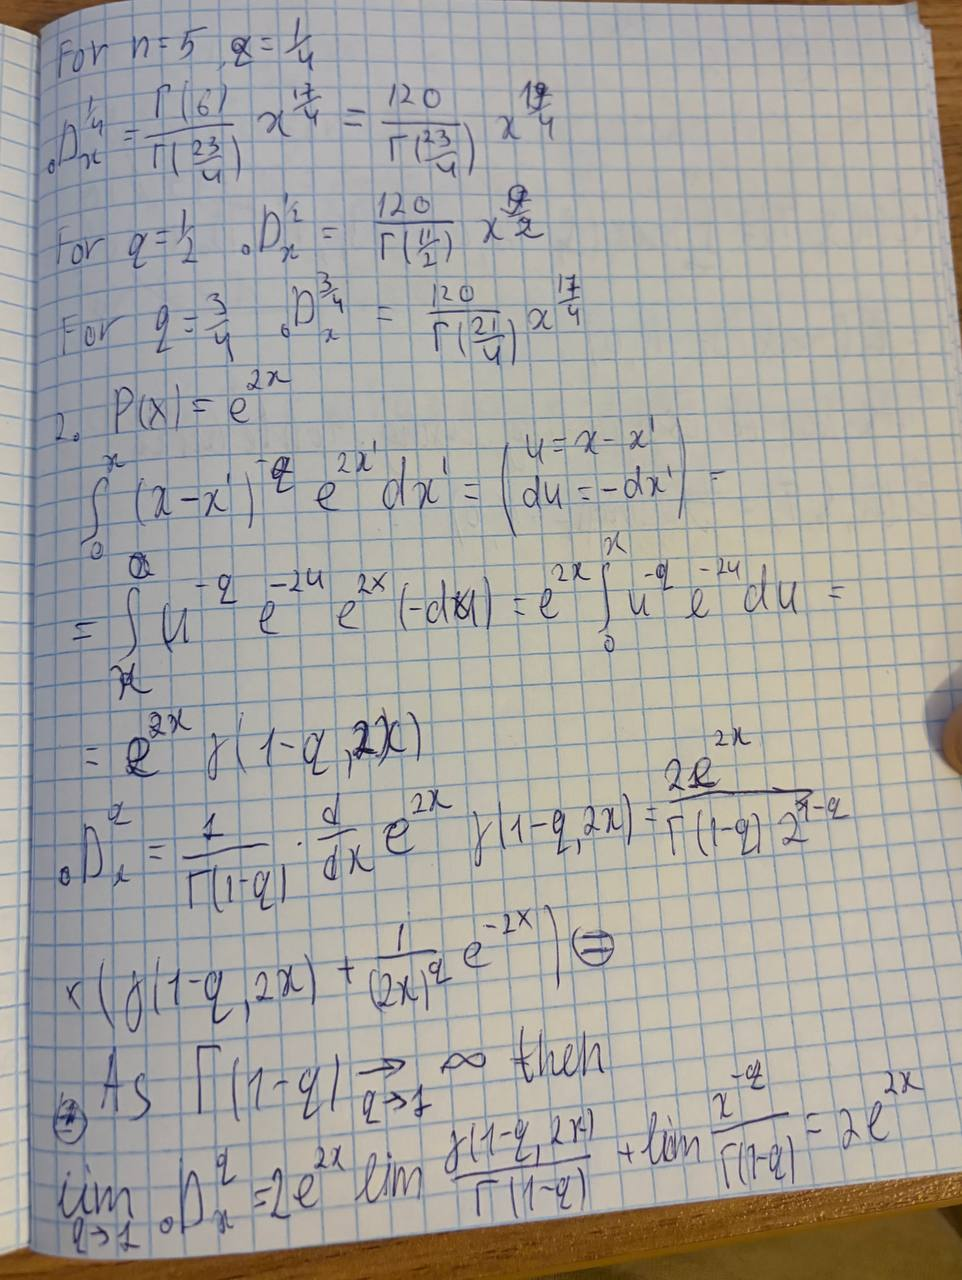

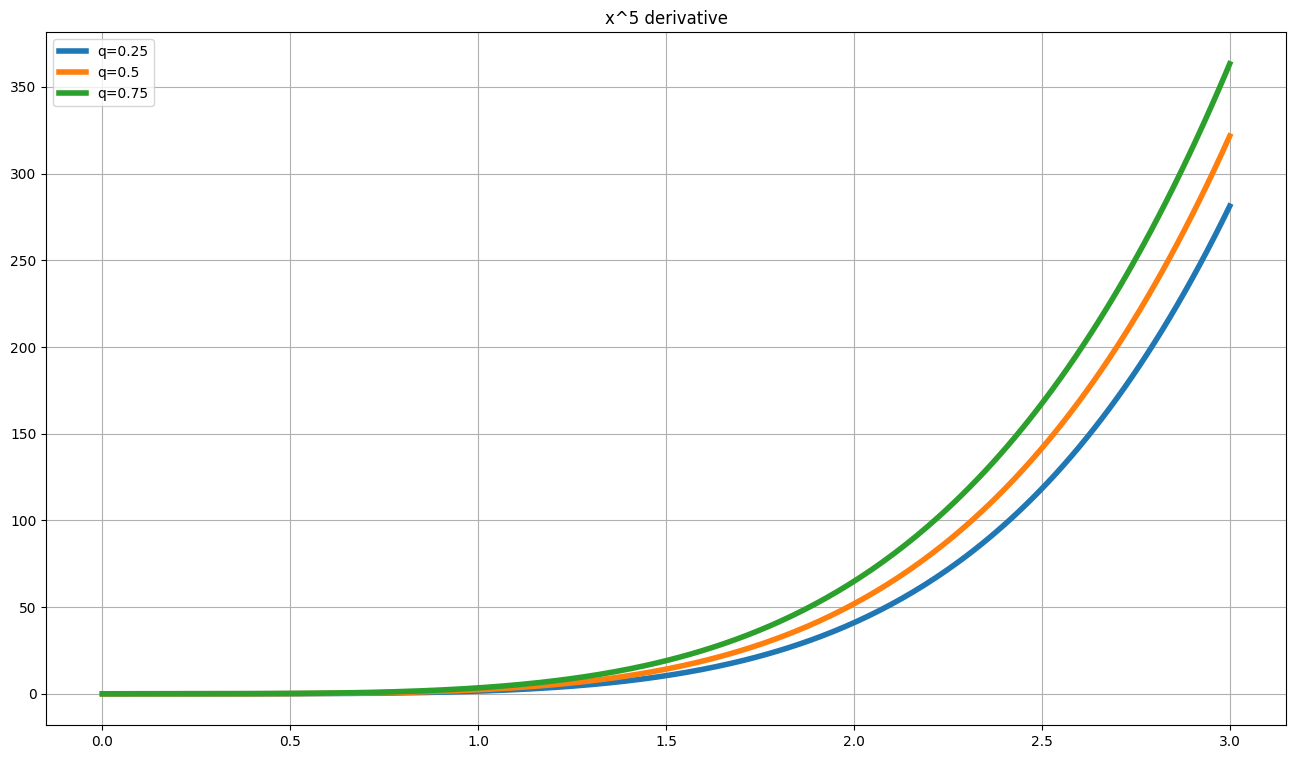

/tmp/ipykernel_11927/546139752.py:11: RuntimeWarning: divide by zero encountered in divide
  return 2 * np.exp(2 * x) *(gammainc(1 - q, 2 * x) + np.exp(-2*x)/(2 * x)**q) / gamma(1 - q) / 2**(1 - q)


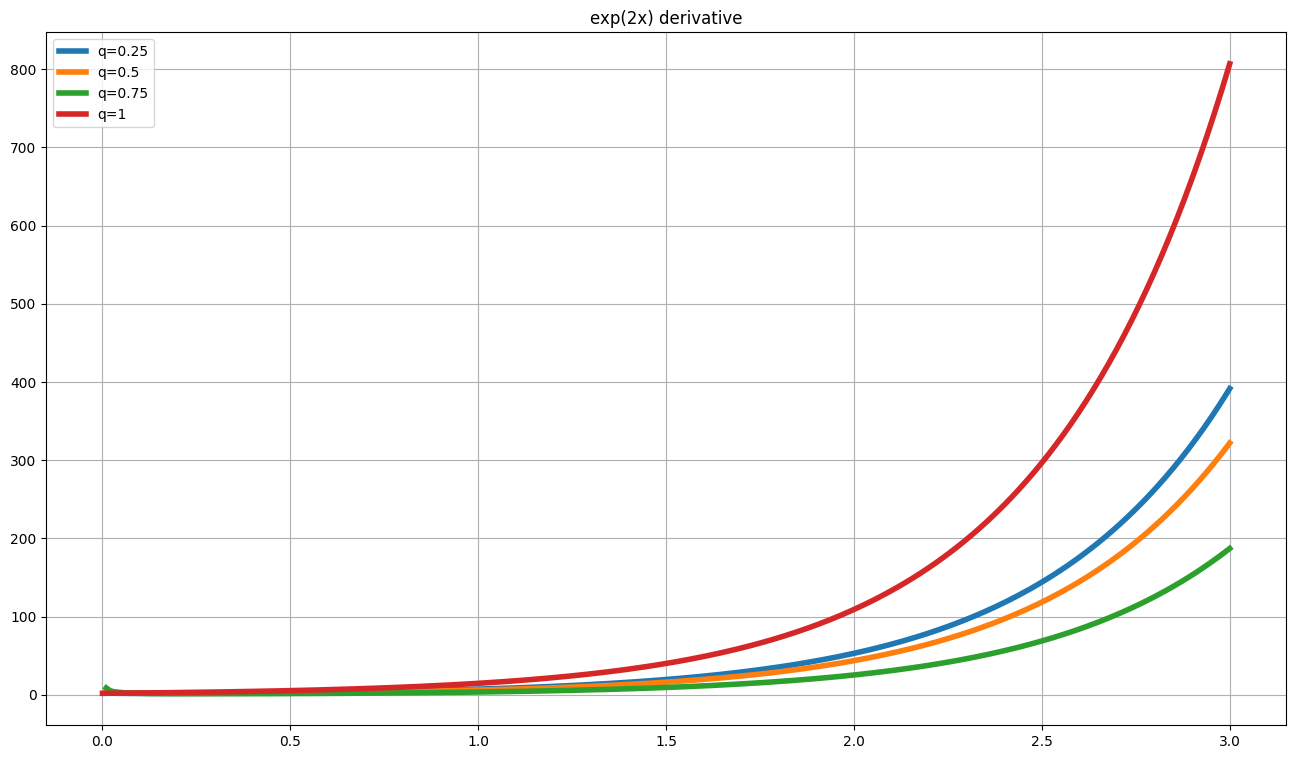

In [140]:
import numpy as np
from scipy.special import gamma, gammainc

def x_derivative(x: np.ndarray, n: int, q: float) -> np.ndarray:
    """Compute the x^n derivative."""
    return gamma(n + 1) * x**(n - q) / gamma(n - q + 1)

def exponenta_derivative(x: np.ndarray, q: float) -> float:
    """Compute the integral of the x-derivative of the function."""
    if q < 1:
        return 2 * np.exp(2 * x) *(gammainc(1 - q, 2 * x) + np.exp(-2*x)/(2 * x)**q) / gamma(1 - q) / 2**(1 - q)
    else:
        return 2 * np.exp(2 * x)

x = np.linspace(0, 3, 300)
plt.figure(figsize=(16, 9))
plt.plot(x, x_derivative(x, 5, 0.25), label="q=0.25", linewidth=4)
plt.plot(x, x_derivative(x, 5, 0.5), label="q=0.5", linewidth=4)
plt.plot(x, x_derivative(x, 5, 0.75), label="q=0.75", linewidth=4)
plt.title("x^5 derivative")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(16, 9))
plt.plot(x, exponenta_derivative(x, 0.25), label="q=0.25", linewidth=4)
plt.plot(x, exponenta_derivative(x, 0.5), label="q=0.5", linewidth=4)
plt.plot(x, exponenta_derivative(x, 0.75), label="q=0.75", linewidth=4)
plt.plot(x, exponenta_derivative(x, 1), label="q=1", linewidth=4)
plt.title("exp(2x) derivative")
plt.grid(True)
plt.legend()
plt.show()



## Problem 4

In [141]:
import numpy as np

class SuperdiffusionSimulation:
    def __init__(self, dt: float, k: float, rng: np.random.Generator) -> None:
        self.dt = dt
        self.rng = rng
        self.k = k

    def generate_noise(self, size: int, mu: float) -> np.ndarray:
        f: np.ndarray = self.rng.uniform(low=-np.pi/2, high=np.pi/2, size=size)
        w: np.ndarray = -np.log(self.rng.uniform(low=0, high=1, size=size))

        first = np.sin(mu * f) / (np.cos(f) ** (1 / mu))
        second = np.cos((1 - mu) * f) / w

        return first * (second ** ((1 - mu) / mu))

    def next_step(self, x: np.ndarray, mu: float) -> np.ndarray:
        noise = self.generate_noise(len(x), mu)

        return x + (self.k * self.dt) ** (1 / mu) * noise

    def simulate(self, x0: np.ndarray, mu: float, n_steps: int) -> np.ndarray:
        if isinstance(x0, float):
            x0 = np.array([x0])

        trajectories = np.zeros((n_steps, len(x0)))
        trajectories[0] = x0.copy()

        for i in range(1, n_steps):
            trajectories[i] = self.next_step(trajectories[i-1], mu)

        return trajectories


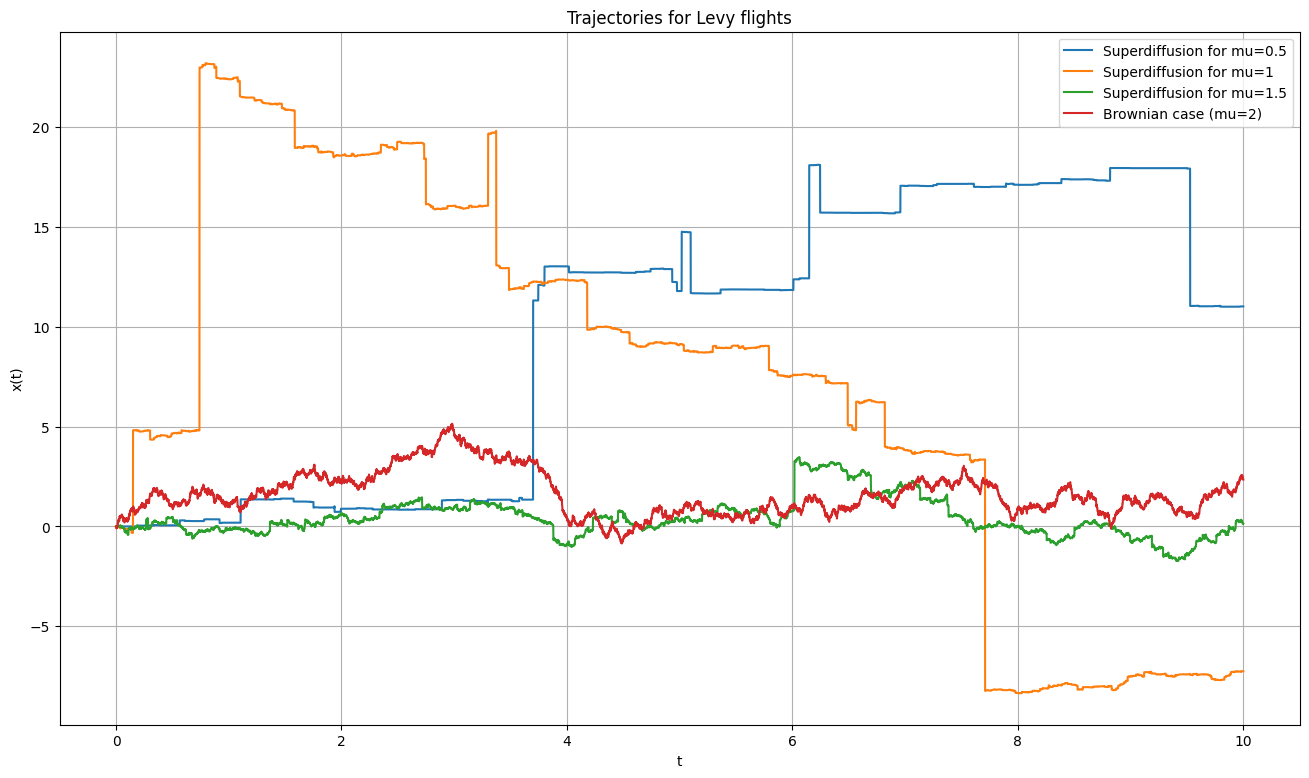

In [142]:
dt = 0.001
n_steps = 10000
k = 1
rng = np.random.default_rng(42)
x0 = np.array([0])
mus = [0.5, 1, 1.5, 2]

sim = SuperdiffusionSimulation(dt=dt, k=k, rng=rng)

time = np.arange(0, n_steps * dt, dt)
plt.figure(figsize=(16, 9))

for mu in mus:
    trajectories = sim.simulate(x0, mu, n_steps)

    label = f"Superdiffusion for mu={mu}" if mu != 2 else "Brownian case (mu=2)"

    plt.plot(time, trajectories[:, 0], label=label)


plt.title("Trajectories for Levy flights")
plt.grid(True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.show()




To plot the PDF lets use function view in Fourier  k-space and then perform invert Fourie Transform on it

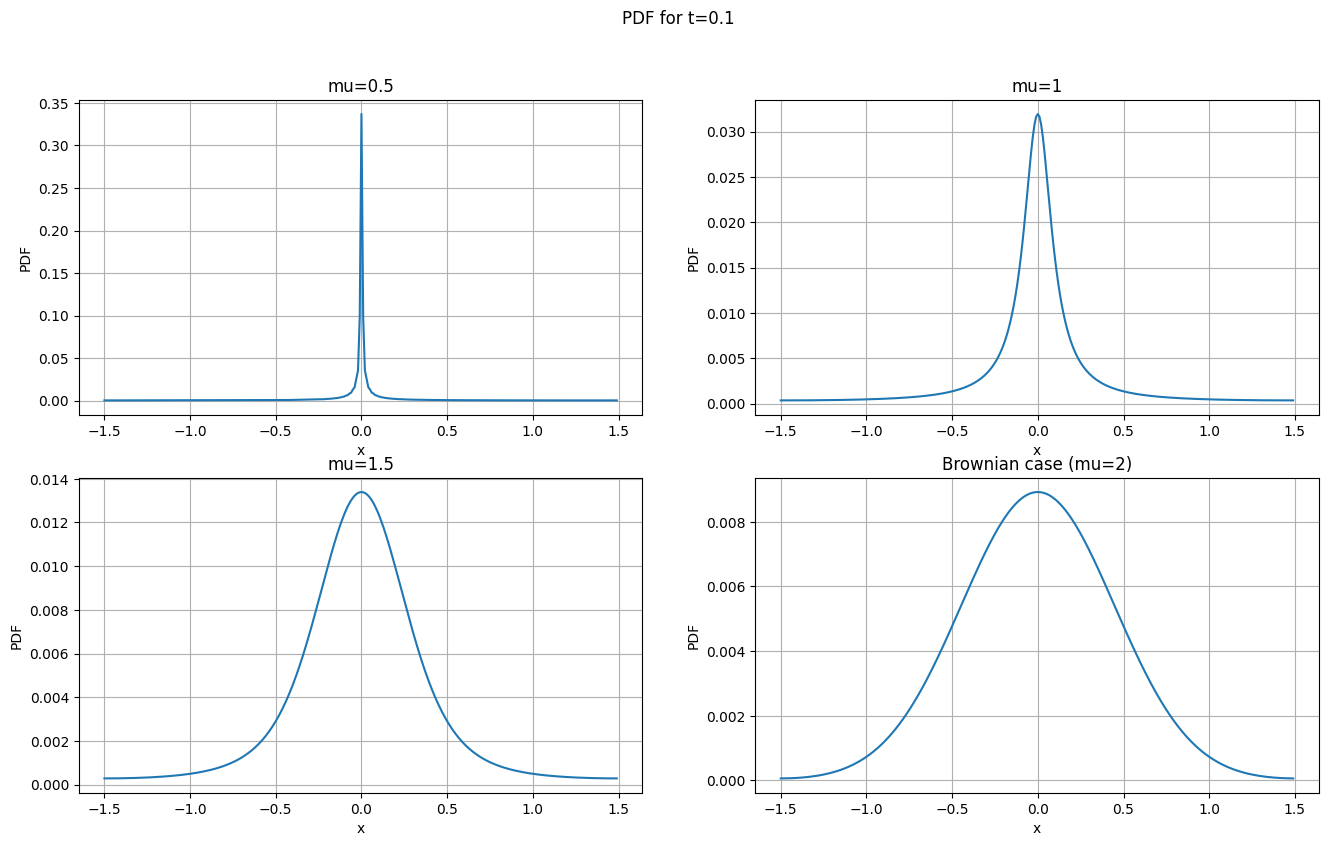

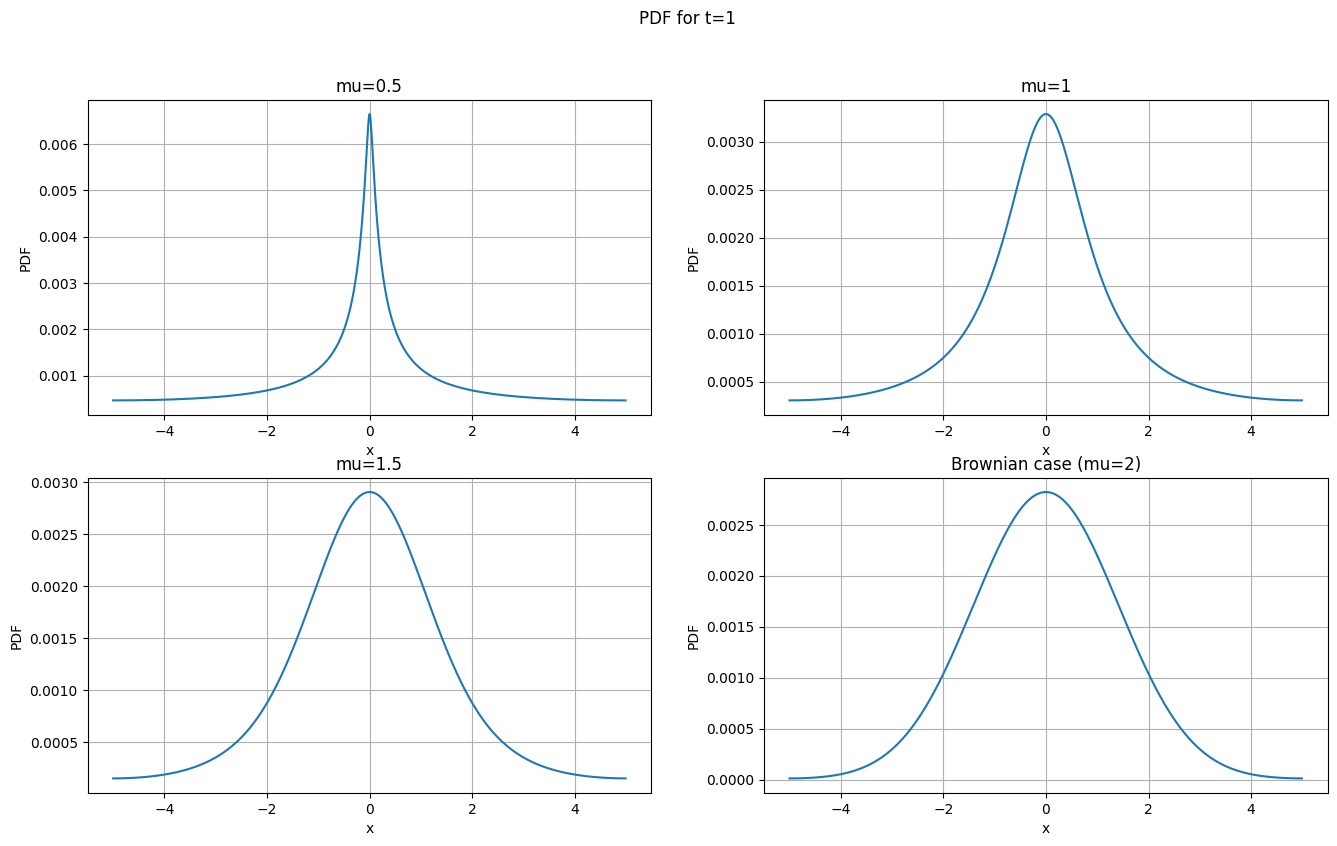

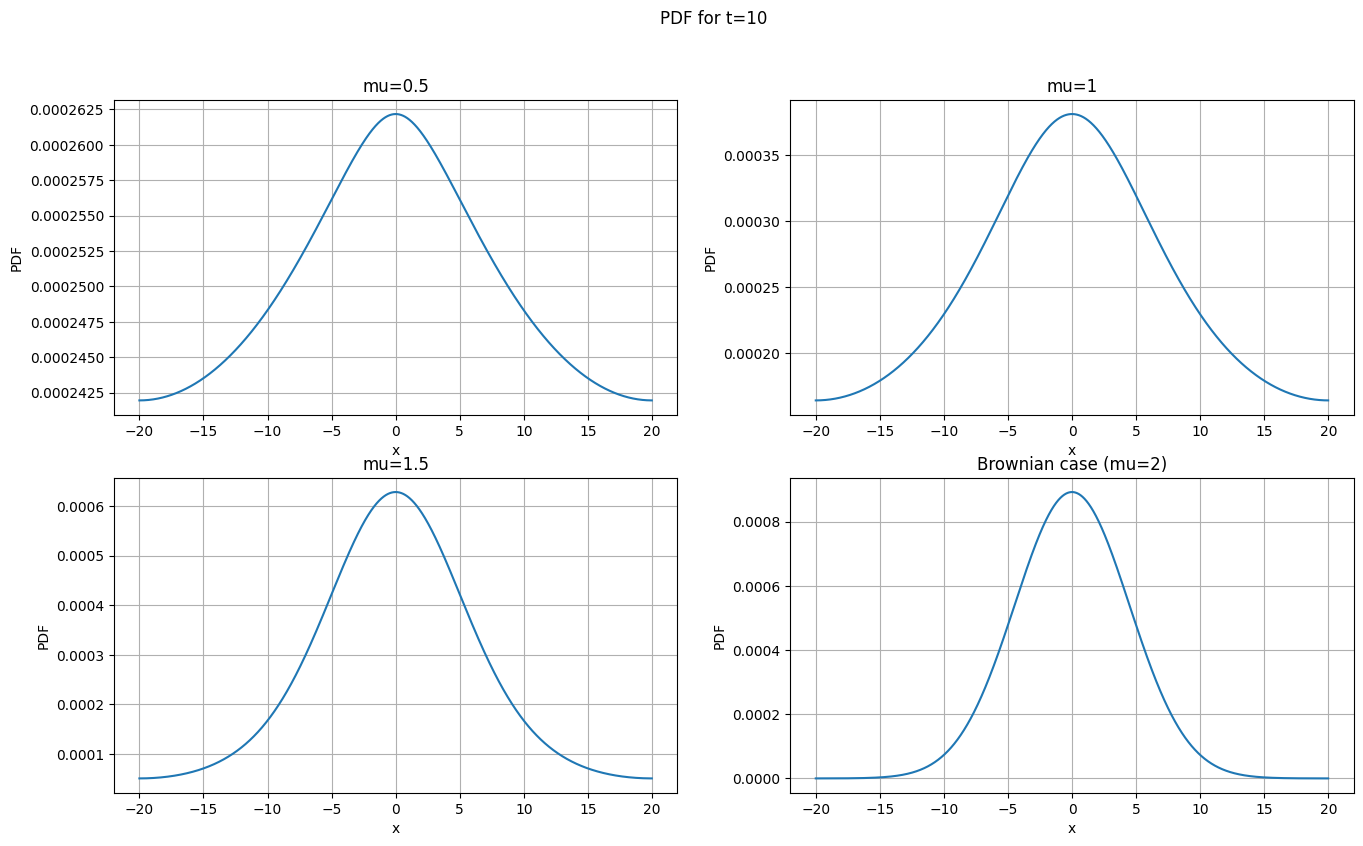

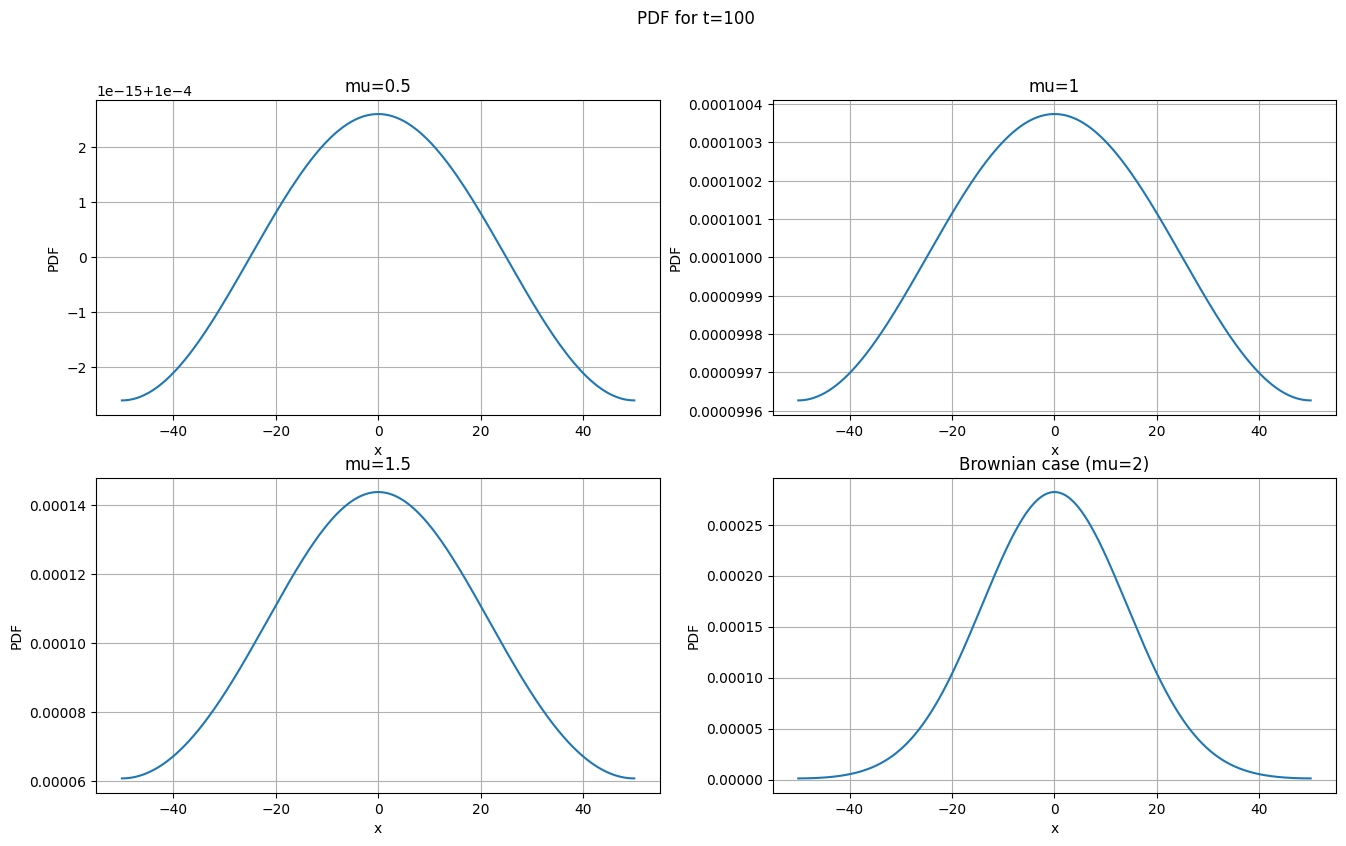

In [143]:
def compute_pdf(n: int, dx: float , t: float, mu: float, K: float) -> tuple[np.ndarray, np.ndarray]:
    """Compute the PDF of the Levy flight."""
    x = np.linspace(-n*dx/2, n*dx/2, n, endpoint=False)
    k = np.fft.fftfreq(len(x), d=dx) * 2 * np.pi
    p_k = np.exp(-K * t * np.abs(k)**mu)
    p_x = np.fft.fftshift(np.real(np.fft.ifft(p_k)))

    return x, p_x

ts = [0.1, 1, 10, 100]
mus = [0.5, 1, 1.5, 2]
K = 1

N = [300, 1000, 4000, 10000]
dx = [0.01, 0.01, 0.01, 0.01]


for i, t in enumerate(ts):

    fig, axes = plt.subplots(2, 2, figsize=(16, 9))

    for j, mu in enumerate(mus):
        x, pdf = compute_pdf(N[i], dx[i], t, mu, K)
        label = f"mu={mu}" if mu != 2 else "Brownian case (mu=2)"
        first, second = j//2, j%2
        axes[first, second].plot(x, pdf)
        axes[first, second].grid(True)
        axes[first, second].set_xlabel("x")
        axes[first, second].set_ylabel("PDF")
        axes[first, second].set_title(label)


    fig.suptitle(f"PDF for t={t}")
    plt.show()

Lets check the x asymptotic

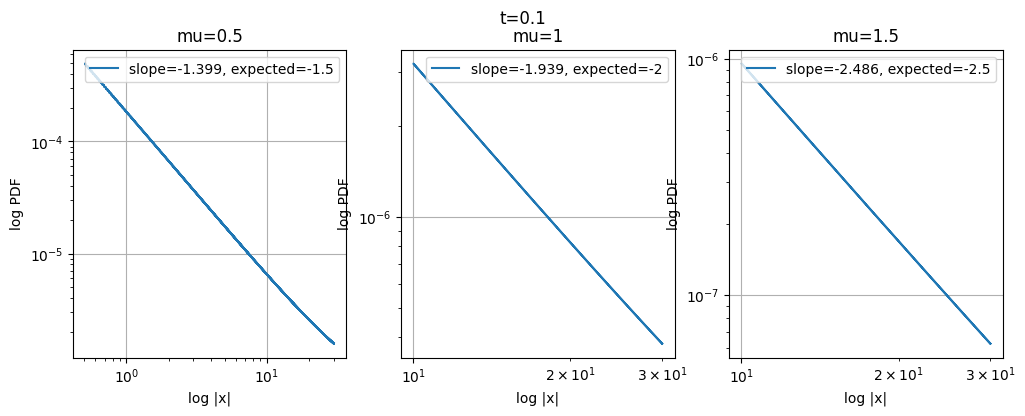

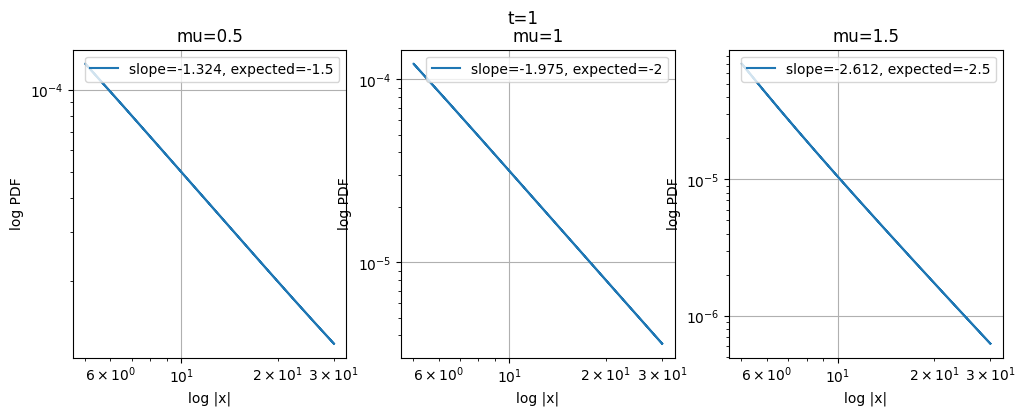

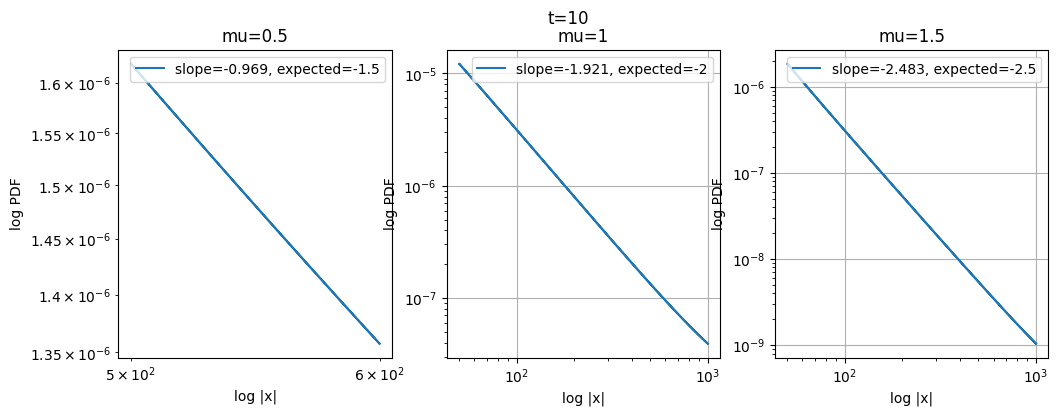

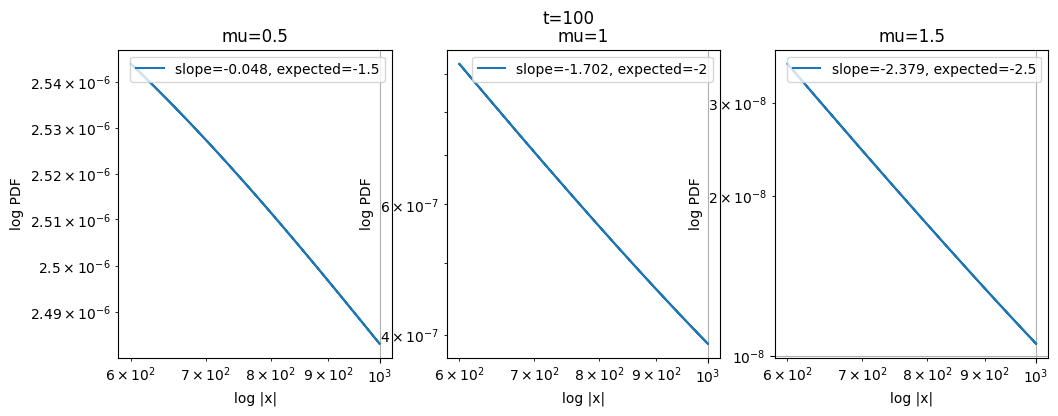

In [144]:
N_list = [20000, 40000, 400000, 400000]
dx_list = [0.01, 0.01, 0.01, 0.01]

#X range for assymptotic check
x_range = [[[0.5, 30], [10, 30], [10, 30], [10, 30]],
           [[5, 30], [5, 30], [5, 30], [5, 30]],
           [[500, 600], [50, 1000], [50, 1000], [50, 1000]],
           [[600, 1000], [600, 1000], [600, 1000], [600, 1000]]]

for i, t in enumerate(ts):
    N = N_list[i]
    dx = dx_list[i]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for j, mu in enumerate(mus):
        if mu == 2:
            continue

        x, pdf = compute_pdf(N, dx, t, mu, K)
        x_abs = np.abs(x)
        mask = (x_abs > x_range[i][j][0]) & (x_abs < x_range[i][j][1])
        slope, _ = np.polyfit(np.log(x_abs[mask]), np.log(pdf[mask]), 1)
        axes[j].loglog(x_abs[mask], pdf[mask], label=f"slope={slope:.3f}, expected={-(1+mu)}")
        axes[j].grid(True)
        axes[j].legend()
        axes[j].set_xlabel("log |x|")
        axes[j].set_ylabel("log PDF")
        axes[j].set_title(f"mu={mu}" if mu != 2 else "Brownian case (mu=2)")

    fig.suptitle(f"t={t}")
    plt.show()

## Problem 5

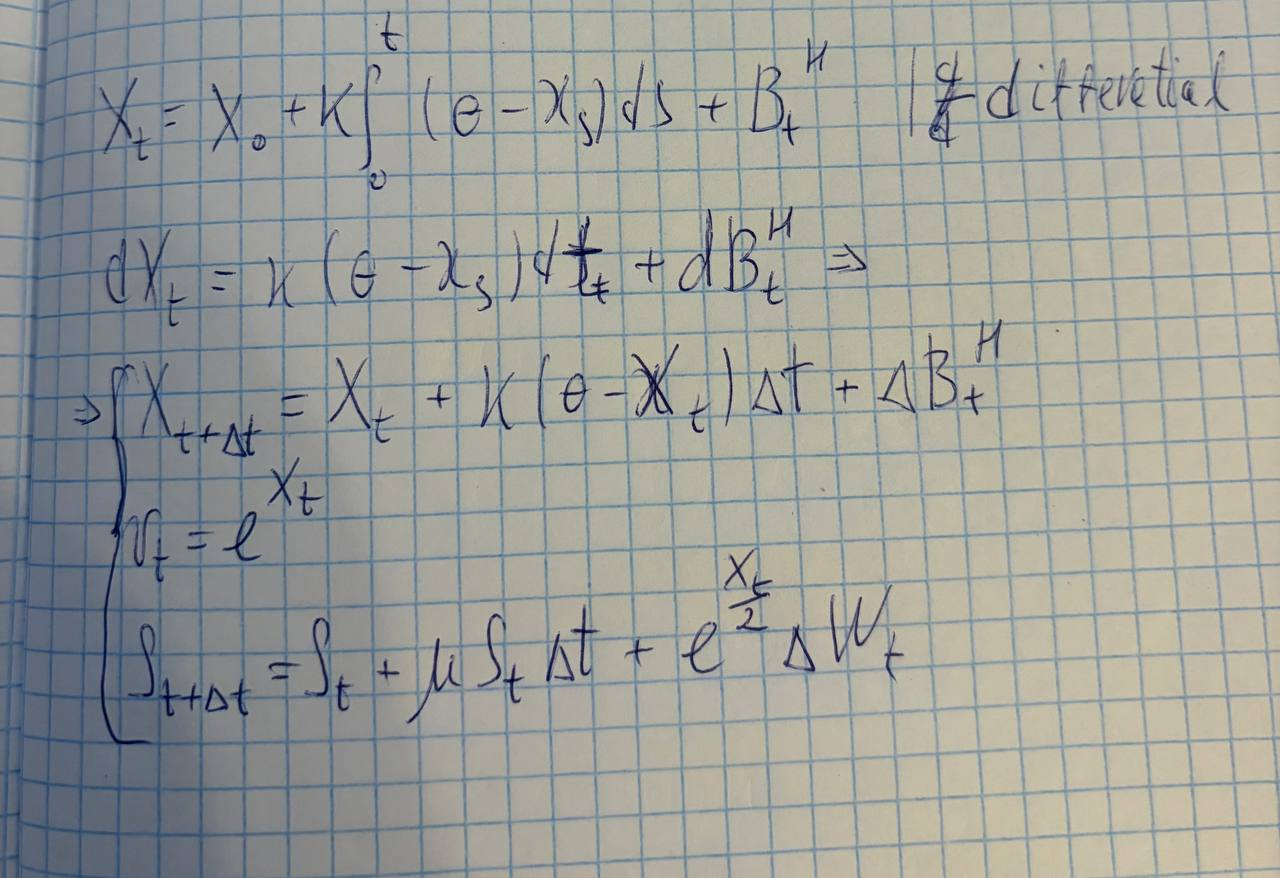

In [1]:
import numpy as np

from fbm import FBM

from matplotlib import pyplot as plt

class StockPrice():

    def __init__(self, mu: float, theta: float, k: float, H: float, dt: float, rng: np.random.Generator, eta: float = 0.3) -> None:
        """
        Rough volatility model

        Parameter eta is used for noise scaling to improve stability
        """
        self.mu = mu
        self.theta = theta
        self.k = k
        self.H = H
        self.dt = dt
        self.rng = rng
        self.eta = eta

    def next_step(self, x: float, s: float, dw: float, db: float) -> float:
        new_x = x + self.k * (self.theta - x) * self.dt + self.eta * db

        vol = np.exp(x)
        new_s = s + self.mu * s * self.dt + np.sqrt(vol) * s * dw

        return new_x, new_s

    def get_db_fgn(self, n_steps: int) -> np.ndarray:
        fbm = FBM(n=n_steps, hurst=self.H, length=n_steps*self.dt)
        return fbm.fgn()

    def simulate(self, x0: float, s0: float, n_steps: int) -> tuple[np.ndarray, np.ndarray]:
        x = np.zeros(n_steps)
        s = np.zeros(n_steps)
        x[0] = x0
        s[0] = s0

        dw = self.rng.normal(size=n_steps) * np.sqrt(self.dt)

        db = self.get_db_fgn(n_steps)

        for i in range(1, n_steps):
            x[i], s[i] = self.next_step(x[i-1], s[i-1], dw[i-1], db[i-1])

        return x, s



In [2]:
import yfinance as yf


apple_data = yf.download('AAPL', start='2020-01-01', end='2025-12-31')


/tmp/ipykernel_41570/2505238294.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple_data = yf.download('AAPL', start='2020-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

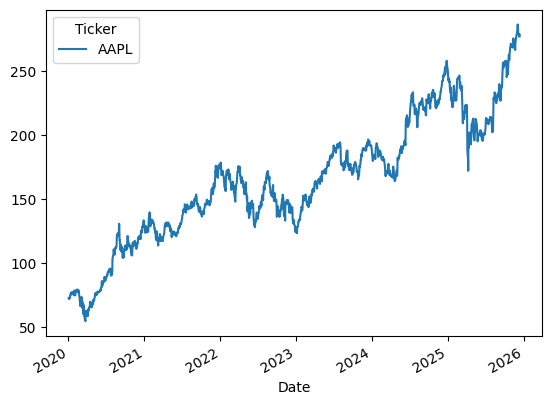

In [3]:
apple_data['Close'].dropna().copy().sort_index().plot()

/tmp/ipykernel_41570/3865408021.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x[i], s[i] = self.next_step(x[i-1], s[i-1], dw[i-1], db[i-1])


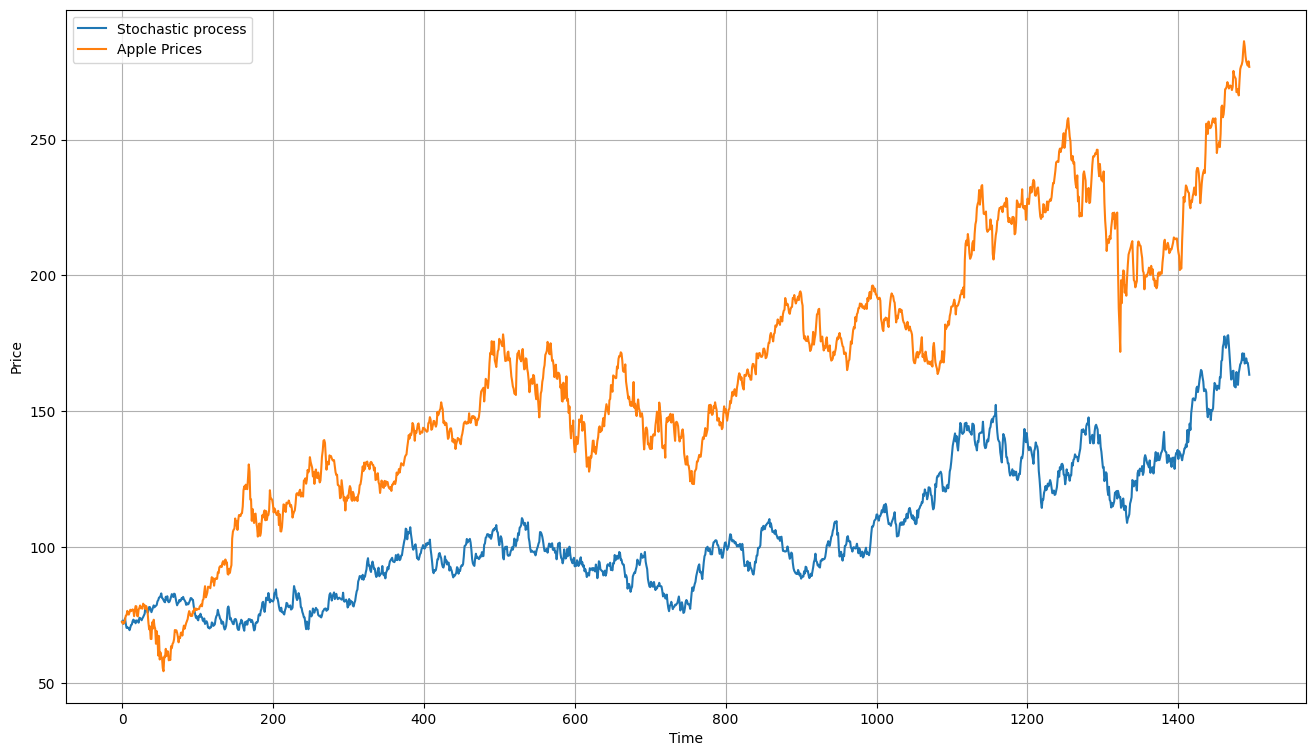

In [28]:
prices = apple_data['Close'].dropna().copy().sort_index()
logrets_obs = np.log(prices).diff().dropna()
mu = logrets_obs.mean() * 252.0
s0 = prices.iloc[0].to_numpy()[0]
eta = 0.4

# Calculate realized volatility series
realized_vol = logrets_obs.rolling(window=30).std(ddof=1) * np.sqrt(252)
realized_vol = realized_vol.iloc[:, 0].dropna()
log_vol_series = 2 * np.log(realized_vol).dropna()

x0 = log_vol_series.iloc[0]
theta = log_vol_series.mean()

k = 1.9
H = 0.1
n_steps = prices.shape[0]
dt = 1/252
rng = np.random.default_rng(42)

stock = StockPrice(mu=mu, theta=theta, k=k, H=H, dt=dt, rng=rng, eta=eta)
x, s = stock.simulate(x0=x0, s0=s0, n_steps=n_steps)

plt.figure(figsize=(16, 9))
plt.plot(s, label="Stochastic process")
plt.plot(prices.to_numpy().flatten(), label="Apple Prices")
plt.legend()
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

#### European call option price

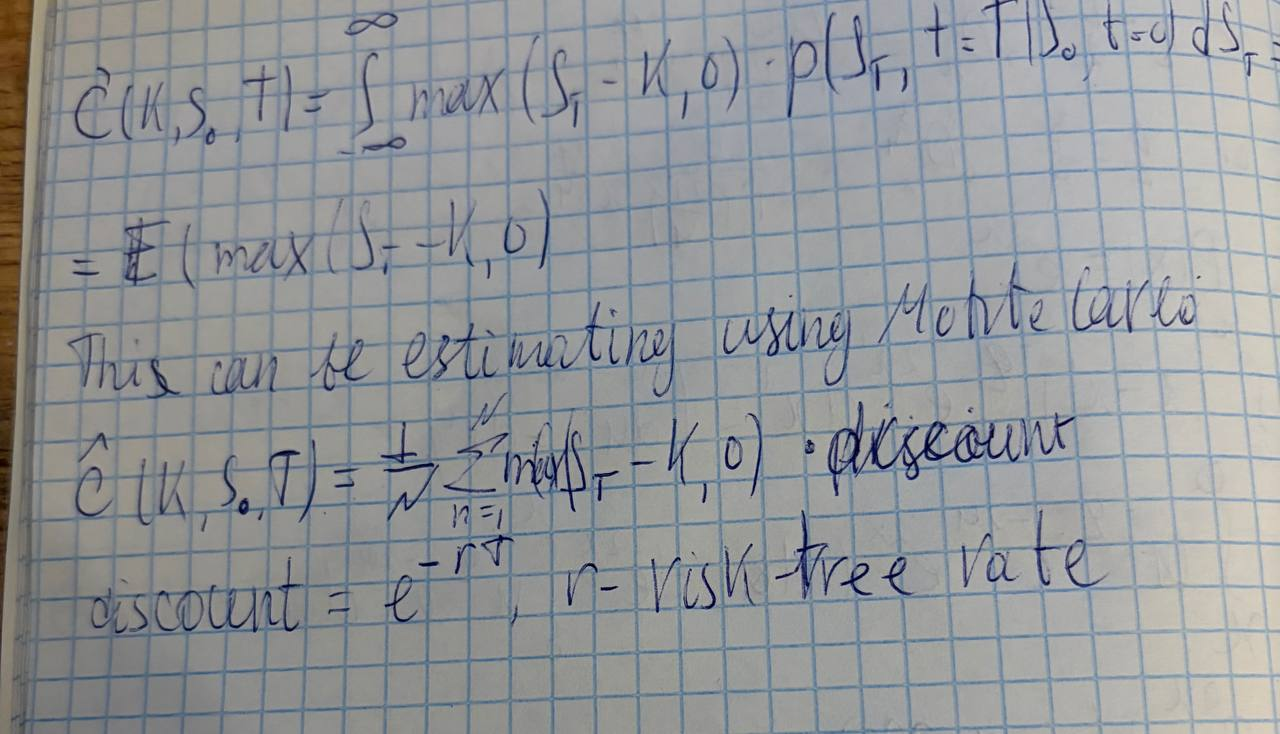

In [ ]:
#Sample trajectories

num_samples = 1000
max_T = 1.0 # 1 year
r = 0.02

stock = StockPrice(mu=r, theta=theta, k=k, H=H, dt=dt, rng=rng, eta=eta)

n_steps = int(max_T / dt)

trajectories = np.zeros((num_samples, n_steps))

for i in range(num_samples):
    trajectories[i] = stock.simulate(x0=x0, s0=s0, n_steps=n_steps)[1]

n_T = trajectories.shape[1]

maturities = np.arange(n_T) * dt


In [ ]:
#Sample call option prove

# As in Black–Scholes formula we have K*e^{-rT} lets scale k range on this parameter to get reasonable range
F_T = s0 * np.exp(r * max_T)
K_range = np.linspace(0.5, 1.5, 100) * F_T

call_price = np.zeros((len(K_range), n_T))

for j, Tj in enumerate(maturities):
    ST = trajectories[:, j]
    discount = np.exp(-r * Tj)
    for i, K in enumerate(K_range):
        payoff = np.maximum(ST - K, 0)
        call_price[i, j] = discount * np.mean(payoff)


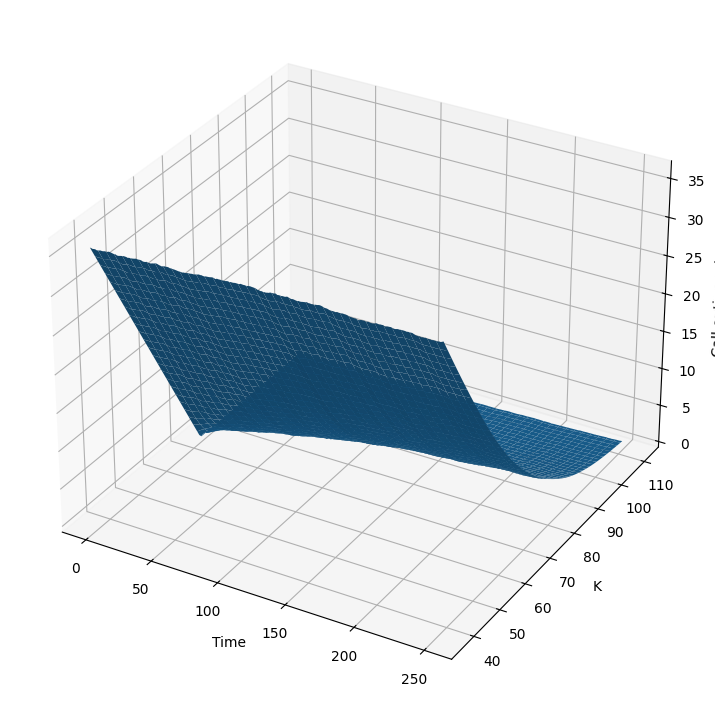

In [9]:
X, Y = np.meshgrid(np.arange(trajectories.shape[1]), K_range)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(16, 9))
ax.plot_surface(X, Y, call_price, vmin=call_price.min() * 2)

ax.set_xlabel("Time")
ax.set_ylabel("K")
ax.set_zlabel("Call option price")

plt.show()

In [ ]:
# Define computation of The Black–Scholes option price and function for finding best sigma

from scipy.stats import norm

from tqdm import tqdm
from scipy.optimize import brentq


def compute_black_scholes_price(S: float, T: float, K: float, r: float, sigma: float) -> float:
    if T <= 0 or sigma <= 0 or K <= 0:
        return max(S - K, 0.0)

    sqrt_T = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / sqrt_T
    d2 = d1 - sqrt_T

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def implied_vol(C_target: float, S0: float, K: float, r: float, T: float, sigma_bounds: tuple[float, float]) -> float:
    """Find implied vol via scipy brentq"""
    if T <= 0 or K <= 0 or C_target <= 0:
        return np.nan

    low, high = sigma_bounds

    def f(sig: float) -> float:
        return compute_black_scholes_price(S0, T, K, r, sig) - C_target

    f_low, f_high = f(low), f(high)
    if np.sign(f_low) == np.sign(f_high):
        return np.nan

    try:
        return brentq(f, low, high, maxiter=100)
    except ValueError:
        return np.nan


In [ ]:
# Finding best sigma

sigma_bounds = (1e-4, 4.0)
sigma = np.full_like(call_price, np.nan, dtype=float)

a = len(K_range)
for i, K in tqdm(enumerate(K_range), total=len(K_range)):
    if K <= 0:
        continue

    for j, Tj in enumerate(maturities):
        if Tj <= 0:
            continue

        C_obs = call_price[i, j]

        if C_obs <= 0:
            continue

        sigma[i, j] = implied_vol(C_obs, s0, K, r, Tj, sigma_bounds)

100%|██████████| 100/100 [00:24<00:00,  4.08it/s]


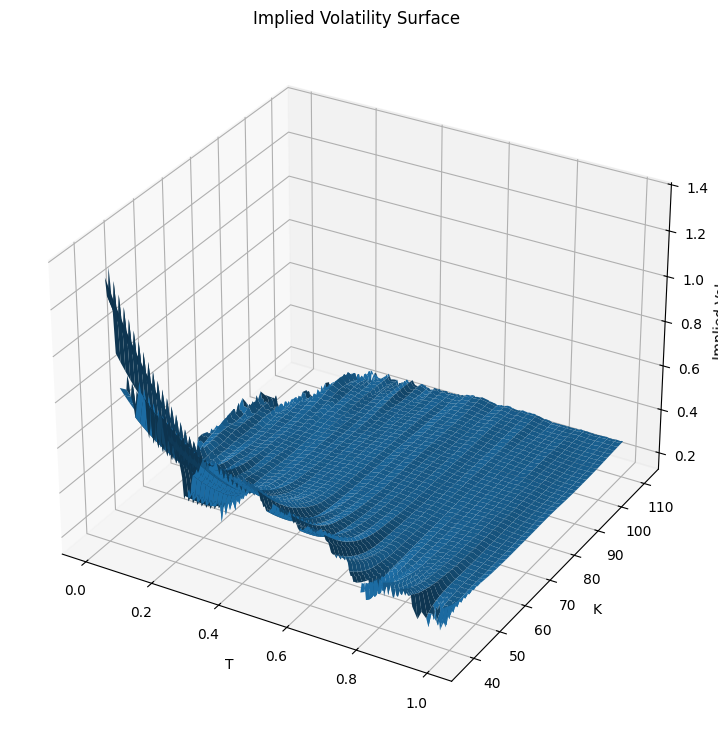

In [29]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(16, 9))

X_mesh, Y_mesh = np.meshgrid(maturities, K_range)
ax.plot_surface(X_mesh, Y_mesh, sigma)

ax.set_xlabel("T")
ax.set_ylabel("K")
ax.set_zlabel("Implied Vol")
ax.set_title("Implied Volatility Surface")

plt.show()

/tmp/ipykernel_38179/221894173.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


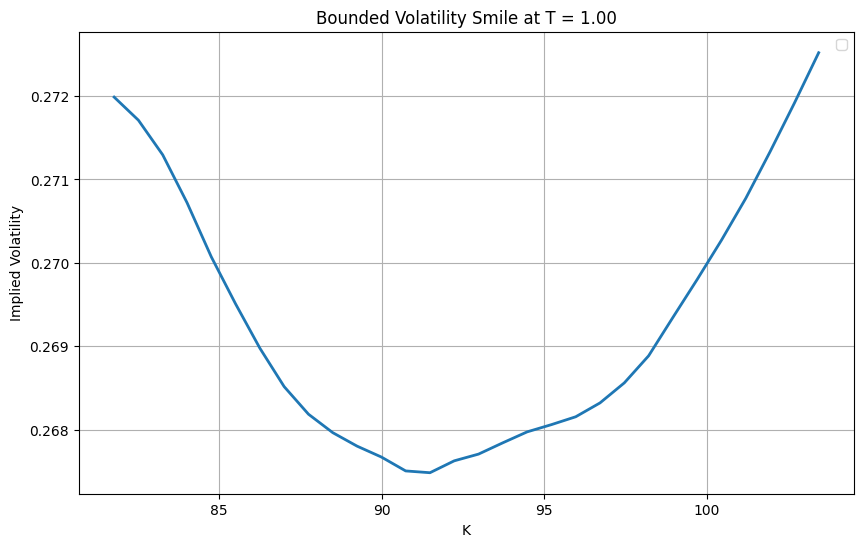

/tmp/ipykernel_38179/221894173.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


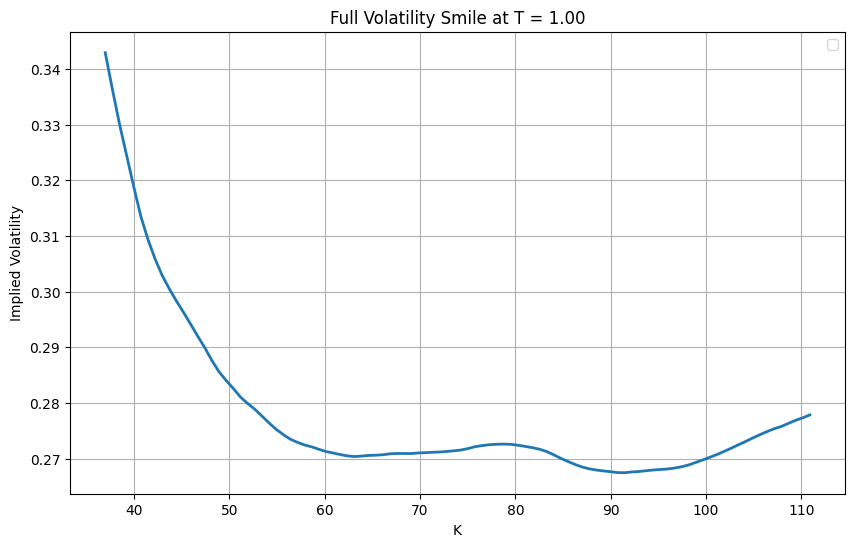

In [24]:
T_idx = -1
T_val = maturities[T_idx]

plt.figure(figsize=(10, 6))
plt.plot(K_range[60:90], sigma[60:90, T_idx], linewidth=2)
plt.xlabel("K")
plt.ylabel("Implied Volatility")
plt.title(f"Bounded Volatility Smile at T = {T_val:.2f}")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(K_range, sigma[:, T_idx], linewidth=2)
plt.xlabel("K")
plt.ylabel("Implied Volatility")
plt.title(f"Full Volatility Smile at T = {T_val:.2f}")
plt.grid(True)
plt.legend()
plt.show()